In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

DATA INGESTION

In [2]:
#LOADING DATASET
transactions = pd.read_csv("transaction_data.csv")
products = pd.read_csv("product.csv")
demographics = pd.read_csv("hh_demographic.csv")
coupons = pd.read_csv("coupon_redempt.csv")

In [3]:
# TRANSACTIONS DATASET INSPECTION
print(transactions.shape)
print(transactions.head())
transactions.info()


(2596232, 12)
   household_key    BASKET_ID  DAY  PRODUCT_ID  QUANTITY  SALES_VALUE  \
0           2375  26984851472    1     1004906         1         1.39   
1           2375  26984851472    1     1033142         1         0.82   
2           2375  26984851472    1     1036325         1         0.99   
3           2375  26984851472    1     1082185         1         1.21   
4           2375  26984851472    1     8160430         1         1.50   

   STORE_ID  RETAIL_DISC  TRANS_TIME  WEEK_NO  COUPON_DISC  COUPON_MATCH_DISC  
0       364        -0.60        1631        1          0.0                0.0  
1       364         0.00        1631        1          0.0                0.0  
2       364        -0.30        1631        1          0.0                0.0  
3       364         0.00        1631        1          0.0                0.0  
4       364        -0.39        1631        1          0.0                0.0  
<class 'pandas.DataFrame'>
RangeIndex: 2596232 entries, 0 to 259623

In [4]:
# PRODUCTS DATASET INSPECTION
print(products.shape)   
print(products.head())
products.info()

(92353, 7)
   PRODUCT_ID  MANUFACTURER    DEPARTMENT     BRAND            COMMODITY_DESC  \
0       25671             2       GROCERY  National                  FRZN ICE   
1       26081             2  MISC. TRANS.  National  NO COMMODITY DESCRIPTION   
2       26093            69        PASTRY   Private                     BREAD   
3       26190            69       GROCERY   Private      FRUIT - SHELF STABLE   
4       26355            69       GROCERY   Private             COOKIES/CONES   

            SUB_COMMODITY_DESC CURR_SIZE_OF_PRODUCT  
0          ICE - CRUSHED/CUBED                22 LB  
1  NO SUBCOMMODITY DESCRIPTION                       
2         BREAD:ITALIAN/FRENCH                       
3                  APPLE SAUCE                50 OZ  
4            SPECIALTY COOKIES                14 OZ  
<class 'pandas.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                -----

In [5]:
# DEMOGRAPHICS DATASET INSPECTION
print(demographics.shape)
print(demographics.head())
demographics.info()
  

(801, 8)
  AGE_DESC MARITAL_STATUS_CODE INCOME_DESC HOMEOWNER_DESC      HH_COMP_DESC  \
0      65+                   A      35-49K      Homeowner  2 Adults No Kids   
1    45-54                   A      50-74K      Homeowner  2 Adults No Kids   
2    25-34                   U      25-34K        Unknown     2 Adults Kids   
3    25-34                   U      75-99K      Homeowner     2 Adults Kids   
4    45-54                   B      50-74K      Homeowner     Single Female   

  HOUSEHOLD_SIZE_DESC KID_CATEGORY_DESC  household_key  
0                   2      None/Unknown              1  
1                   2      None/Unknown              7  
2                   3                 1              8  
3                   4                 2             13  
4                   1      None/Unknown             16  
<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               -------

In [6]:
# COUPONS DATASET INSPECTION
print(coupons.shape)                
print(coupons.head())
coupons.info()

(2368, 4)
   household_key  DAY   COUPON_UPC  CAMPAIGN
0              1  421  10000085364         8
1              1  421  51700010076         8
2              1  427  54200000033         8
3              1  597  10000085476        18
4              1  597  54200029176        18
<class 'pandas.DataFrame'>
RangeIndex: 2368 entries, 0 to 2367
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   household_key  2368 non-null   int64
 1   DAY            2368 non-null   int64
 2   COUPON_UPC     2368 non-null   int64
 3   CAMPAIGN       2368 non-null   int64
dtypes: int64(4)
memory usage: 74.1 KB


In [7]:
quality_report = pd.DataFrame({
    "Dataset":[
        "Transactions",
        "Products",
        "Demographics",
        "Coupons"
    ],
    
    "Rows":[
        transactions.shape[0],
        products.shape[0],
        demographics.shape[0],
        coupons.shape[0]
    ],
    
    "Columns":[
        transactions.shape[1],
        products.shape[1],
        demographics.shape[1],
        coupons.shape[1]
    ],
    
    "Missing Values":[
        transactions.isnull().sum().sum(),
        products.isnull().sum().sum(),
        demographics.isnull().sum().sum(),
        coupons.isnull().sum().sum()
    ],
    
    "Duplicate Rows":[
        transactions.duplicated().sum(),
        products.duplicated().sum(),
        demographics.duplicated().sum(),
        coupons.duplicated().sum()
    ],
    
    "Unique Records":[
        transactions.drop_duplicates().shape[0],
        products.drop_duplicates().shape[0],
        demographics.drop_duplicates().shape[0],
        coupons.drop_duplicates().shape[0]
    ],

    "Unique %":[round((transactions.drop_duplicates().shape[0] /transactions.shape[0])*100,2),
                round((products.drop_duplicates().shape[0] /products.shape[0])*100,2),
                round((demographics.drop_duplicates().shape[0] /demographics.shape[0])*100,2),
                round((coupons.drop_duplicates().shape[0] /coupons.shape[0])*100,2)],

    "Dtypes": [len(transactions.dtypes),
           len(products.dtypes),
           len(demographics.dtypes),
           len(coupons.dtypes)]

})


quality_report.to_csv("before_after_quality_report.csv",index=False)
quality_report

,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Unique Records,Unique %,Dtypes
0,Transactions,2596232,12,0,500,2595732,99.98,12
1,Products,92353,7,1848,0,92353,100.00,7
2,Demographics,801,8,40,0,801,100.00,8
3,Coupons,2368,4,0,50,2318,97.89,4


In [8]:
datasets = {
    "Transactions": transactions,
    "Products": products,
    "Demographics": demographics,
    "Coupons": coupons
}

before_quality = []

for name, df in datasets.items():

    before_quality.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Records": df.duplicated().sum(),
        "Unique Columns with Missing Values": df.isnull().any().sum()
    })

before_quality = pd.DataFrame(before_quality)

before_quality



,Dataset,Rows,Columns,Missing Values,Duplicate Records,Unique Columns with Missing Values
0,Transactions,2596232,12,0,500,0
1,Products,92353,7,1848,0,2
2,Demographics,801,8,40,0,2
3,Coupons,2368,4,0,50,0


In [9]:
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(name)
        print(missing)

Products
COMMODITY_DESC        924
SUB_COMMODITY_DESC    924
dtype: int64
Demographics
INCOME_DESC       24
HOMEOWNER_DESC    16
dtype: int64


In [10]:
products[products[["COMMODITY_DESC", "SUB_COMMODITY_DESC"]].isnull().any(axis=1)]
demographics[demographics[["INCOME_DESC", "HOMEOWNER_DESC"]].isnull().any(axis=1)]


,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
63,25-34,A,NaN,NaN,1 Adult Kids,5+,3+,178
65,45-54,A,NaN,NaN,Single Male,2,None/Unknown,192
66,45-54,A,NaN,NaN,2 Adults No Kids,2,None/Unknown,193
67,35-44,A,NaN,NaN,2 Adults Kids,3,1,198
244,45-54,U,NaN,Homeowner,2 Adults No Kids,2,None/Unknown,731
286,25-34,U,NaN,NaN,Single Female,1,None/Unknown,859
327,35-44,A,NaN,NaN,2 Adults Kids,4,2,973
346,35-44,A,NaN,NaN,2 Adults Kids,5+,3+,1021
377,35-44,U,NaN,Unknown,2 Adults No Kids,2,None/Unknown,1138
395,35-44,A,NaN,NaN,2 Adults No Kids,2,None/Unknown,1179


DATA HANDLING

In [11]:
transactions = transactions.drop_duplicates()
coupons = coupons.drop_duplicates()

print('Transactions duplicates:', transactions.duplicated().sum())
print('Coupons duplicates:', coupons.duplicated().sum())

Transactions duplicates: 0
Coupons duplicates: 0


In [12]:
print(products.isnull().sum())
print(demographics.isnull().sum())



PRODUCT_ID                0
MANUFACTURER              0
DEPARTMENT                0
BRAND                     0
COMMODITY_DESC          924
SUB_COMMODITY_DESC      924
CURR_SIZE_OF_PRODUCT      0
dtype: int64
AGE_DESC                0
MARITAL_STATUS_CODE     0
INCOME_DESC            24
HOMEOWNER_DESC         16
HH_COMP_DESC            0
HOUSEHOLD_SIZE_DESC     0
KID_CATEGORY_DESC       0
household_key           0
dtype: int64


In [13]:
products['COMMODITY_DESC'] = products['COMMODITY_DESC'].fillna('Unknown')
products['SUB_COMMODITY_DESC'] = products['SUB_COMMODITY_DESC'].fillna('Unknown')

demographics['INCOME_DESC'] = demographics['INCOME_DESC'].fillna('Unknown')
demographics['HOMEOWNER_DESC'] = demographics['HOMEOWNER_DESC'].fillna('Unknown')

SKU CODE VALIDATION AND STANDARDIZATION

In [14]:
print('Missing product ids:', products['PRODUCT_ID'].isnull().sum())
print('Duplicate product ids:', products['PRODUCT_ID'].duplicated().sum())

missing_sku = (~transactions['PRODUCT_ID'].isin(products['PRODUCT_ID'])).sum()
print('Transaction SKUS not in product dataset:', missing_sku)

Missing product ids: 0
Duplicate product ids: 0
Transaction SKUS not in product dataset: 0


DATA INTEGRATION

In [15]:
retail_df = pd.merge(
    transactions,
    products,
    on="PRODUCT_ID",
    how="left"
)

print(retail_df.shape)
retail_df.head()

(2595732, 18)


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0,69,PRODUCE,Private,POTATOES,POTATOES RUSSET (BULK&BAG),5 LB
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0,2,PRODUCE,National,ONIONS,ONIONS SWEET (BULK&BAG),40 LB
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0,69,PRODUCE,Private,VEGETABLES - ALL OTHERS,CELERY,
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0,69,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,1 LB


In [16]:
retail_df = pd.merge(
    retail_df,
    demographics,
    on="household_key",
    how="left"
)

print(retail_df.shape)
retail_df.head()

(2595732, 25)


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,...,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,...,POTATOES,POTATOES RUSSET (BULK&BAG),5 LB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,...,ONIONS,ONIONS SWEET (BULK&BAG),40 LB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,...,VEGETABLES - ALL OTHERS,CELERY,,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,...,TROPICAL FRUIT,BANANAS,40 LB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,...,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,1 LB,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
coupon_flag = (
    coupons.groupby("household_key")
    .size()
    .reset_index(name="COUPON_COUNT")
)

coupon_flag.head()

,household_key,COUPON_COUNT
0,1,5
1,8,1
2,13,21
3,14,3
4,18,8


In [18]:
retail_df = pd.merge(
    retail_df,
    coupon_flag,
    on="household_key",
    how="left"
)

In [19]:
retail_df["COUPON_COUNT"] = (
    retail_df["COUPON_COUNT"]
    .fillna(0)
)

In [20]:
retail_df["COUPON_USED"] = (
    retail_df["COUPON_COUNT"] > 0
).astype(int)

In [21]:
print(retail_df.shape)

print(retail_df.isnull().sum().sort_values(ascending=False).head(20))

(2595732, 27)
KID_CATEGORY_DESC       1168429
HOUSEHOLD_SIZE_DESC     1168429
HH_COMP_DESC            1168429
HOMEOWNER_DESC          1168429
INCOME_DESC             1168429
MARITAL_STATUS_CODE     1168429
AGE_DESC                1168429
household_key                 0
BRAND                         0
COUPON_COUNT                  0
CURR_SIZE_OF_PRODUCT          0
SUB_COMMODITY_DESC            0
COMMODITY_DESC                0
DEPARTMENT                    0
BASKET_ID                     0
MANUFACTURER                  0
COUPON_MATCH_DISC             0
COUPON_DISC                   0
WEEK_NO                       0
TRANS_TIME                    0
dtype: int64


FEATURE ENGINEERING

TOTAL DISCOUNT

In [22]:
retail_df["TOTAL_DISCOUNT"] = (
    retail_df["RETAIL_DISC"]
    + retail_df["COUPON_DISC"]
    + retail_df["COUPON_MATCH_DISC"]
)

NET SALES

In [23]:
retail_df["NET_SALES"] = (
    retail_df["SALES_VALUE"]
    + retail_df["TOTAL_DISCOUNT"]
)

BASKET VALUE

In [24]:
basket_value = (
    retail_df.groupby("BASKET_ID")["NET_SALES"]
    .sum()
    .reset_index(name="BASKET_VALUE")
)

basket_value.head()

,BASKET_ID,BASKET_VALUE
0,26984851472,4.62
1,26984851516,9.17
2,26984896261,9.19
3,26984905972,0.47
4,26984945254,3.53


PURCHASE FREQUENCY

In [25]:
purchase_frequency = (
    retail_df.groupby("household_key")["BASKET_ID"]
    .nunique()
    .reset_index(name="PURCHASE_FREQUENCY")
)

purchase_frequency.head()

,household_key,PURCHASE_FREQUENCY
0,1,86
1,2,45
2,3,47
3,4,30
4,5,40


In [26]:
retail_df = pd.merge(
    retail_df,
    purchase_frequency,
    on="household_key",
    how="left"
)

In [27]:
retail_df.to_csv(
    "integrated_retail_data.csv",
    index=False
)

In [28]:
retail_df_backup = retail_df.copy()

FEATURE ENCODING

In [29]:
print(retail_df.select_dtypes(include="object").columns.tolist())

['DEPARTMENT', 'BRAND', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 'CURR_SIZE_OF_PRODUCT', 'AGE_DESC', 'MARITAL_STATUS_CODE', 'INCOME_DESC', 'HOMEOWNER_DESC', 'HH_COMP_DESC', 'HOUSEHOLD_SIZE_DESC', 'KID_CATEGORY_DESC']


C:\Users\User\AppData\Local\Temp\ipykernel_13500\3503110574.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(retail_df.select_dtypes(include="object").columns.tolist())


In [30]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

categorical_columns = [
'DEPARTMENT',
 'BRAND', 
 'COMMODITY_DESC', 
 'SUB_COMMODITY_DESC',
 'AGE_DESC', 
 'MARITAL_STATUS_CODE',
'INCOME_DESC',
'HOMEOWNER_DESC', 
'HH_COMP_DESC',
'HOUSEHOLD_SIZE_DESC',
'KID_CATEGORY_DESC'
]

for column in categorical_columns:
    retail_df[column] = label_encoder.fit_transform(retail_df[column].astype(str))

print('Categorical encoding completed successfully!')

Categorical encoding completed successfully!


In [31]:
retail_df[categorical_columns].head()

,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC
0,35,1,234,1692,6,3,13,5,6,5,4
1,35,0,212,1496,6,3,13,5,6,5,4
2,35,1,300,389,6,3,13,5,6,5,4
3,35,0,292,165,6,3,13,5,6,5,4
4,35,1,214,1510,6,3,13,5,6,5,4


In [32]:
print(
    retail_df.select_dtypes(
        include=["object","string"]
    ).columns.tolist()
)

['CURR_SIZE_OF_PRODUCT']


FEATURE SCALING

In [33]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

columns_to_scale = [
    'SALES_VALUE',
    'QUANTITY',
    'TOTAL_DISCOUNT',
    'NET_SALES',
    'PURCHASE_FREQUENCY'
]

retail_df[columns_to_scale] = scaler.fit_transform(retail_df[columns_to_scale])
print('Scaling completed successfully!')
retail_df[columns_to_scale].describe()

Scaling completed successfully!


,SALES_VALUE,QUANTITY,TOTAL_DISCOUNT,NET_SALES,PURCHASE_FREQUENCY
count,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06
mean,3.695381e-03,1.120379e-03,9.752810e-01,1.091105e-01,1.480740e-01
std,4.978898e-03,1.286771e-02,6.957794e-03,4.314679e-03,1.292291e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.535714e-03,1.115598e-05,9.745095e-01,1.073381e-01,6.774442e-02
50%,2.380952e-03,1.115598e-05,9.779336e-01,1.081998e-01,1.147036e-01
75%,4.154762e-03,1.115598e-05,9.783140e-01,1.095828e-01,1.839877e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


EXPLORATORY DATA ANALYSIS (EDA) & BUSINESS INSIGHTS

AGGREGATION ANALYSIS

In [34]:
category_revenue = (
    retail_df_backup.groupby("COMMODITY_DESC")["NET_SALES"].sum().sort_values(ascending=False).head(10)
)
print(category_revenue)

COMMODITY_DESC
COUPON/MISC ITEMS         619616.71
BEEF                      243219.64
SOFT DRINKS               214185.38
FLUID MILK PRODUCTS       157277.43
BEERS/ALES                146589.73
CHEESE                    137892.23
BAG SNACKS                125327.66
FRZN MEAT/MEAT DINNERS    112222.80
FROZEN PIZZA              110568.71
BAKED BREAD/BUNS/ROLLS    108524.28
Name: NET_SALES, dtype: float64


INVENTORY & STOCK ANALYSIS

1) ABC INVENTORY CLASSIFICATION

In [35]:
abc = (
    retail_df_backup.groupby('PRODUCT_ID')['SALES_VALUE']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

abc['Revenue_%'] = (
    abc['SALES_VALUE']
    / abc['SALES_VALUE'].sum()
) * 100

abc['Cumulative_%'] = abc['Revenue_%'].cumsum()

def abc_class(x):
    if x <= 80:
        return 'A'
    elif x <= 95:
        return 'B'
    else:
        return 'C'

abc['ABC_Class'] = abc['Cumulative_%'].apply(abc_class)

display(abc.head(10))

,PRODUCT_ID,SALES_VALUE,Revenue_%,Cumulative_%,ABC_Class
0,6534178,503867.11,6.253421,6.253421,A
1,6533889,46311.32,0.574763,6.828184,A
2,1029743,41072.06,0.509739,7.337924,A
3,6534166,33594.48,0.416936,7.754860,A
4,1082185,29482.00,0.365897,8.120757,A
5,916122,28951.93,0.359318,8.480075,A
6,6533765,28837.27,0.357895,8.837970,A
7,1106523,27818.44,0.345251,9.183221,A
8,995242,26502.46,0.328918,9.512139,A
9,5569230,23651.56,0.293536,9.805675,A


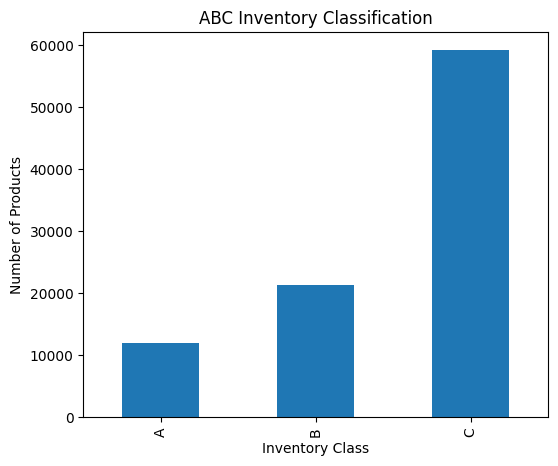

In [36]:
plt.figure(figsize=(6,5))

abc['ABC_Class'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("ABC Inventory Classification")
plt.xlabel("Inventory Class")
plt.ylabel("Number of Products")

plt.show()

The results demonstrate the Pareto Principle (80/20 Rule) in retail inventory management, where a relatively small proportion of products contributes the majority of total revenue. Businesses should prioritize inventory planning, replenishment, and promotional strategies for Category A products, maintain balanced control over Category B products, and optimize storage costs for Category C products to improve overall inventory efficiency.

2)Fast Moving vs Slow Moving Inventory

In [37]:
inventory = (
    retail_df_backup.groupby('PRODUCT_ID')['QUANTITY']
    .sum()
    .reset_index()
)

median_quantity = inventory['QUANTITY'].median()

inventory['Inventory_Class'] = inventory['QUANTITY'].apply(
    lambda x: 'Fast Moving' if x >= median_quantity else 'Slow Moving'
)

display(inventory.head())

,PRODUCT_ID,QUANTITY,Inventory_Class
0,25671,6,Fast Moving
1,26081,1,Slow Moving
2,26093,1,Slow Moving
3,26190,1,Slow Moving
4,26355,2,Slow Moving


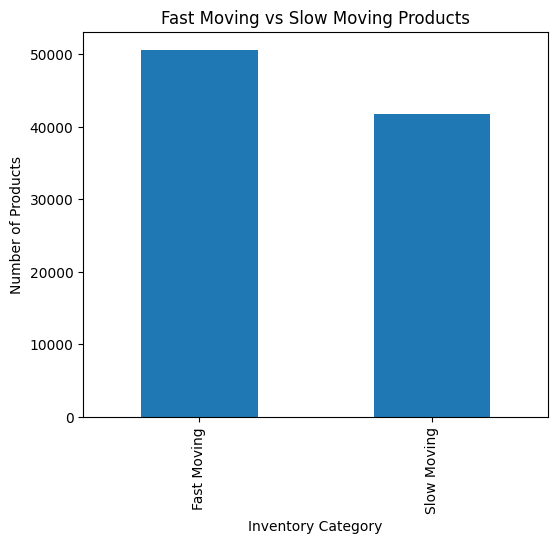

In [38]:
plt.figure(figsize=(6,5))

inventory['Inventory_Class'].value_counts().plot(
    kind='bar'
)

plt.title("Fast Moving vs Slow Moving Products")
plt.xlabel("Inventory Category")
plt.ylabel("Number of Products")

plt.show()

The chart shows that approximately 50,000 products are classified as Fast Moving, while around 42,000 products fall under the Slow Moving category.
Fast Moving Products represent items with relatively higher sales volumes and require frequent replenishment to ensure product availability and avoid stock shortages.Slow Moving Products have comparatively lower sales volumes and may require less frequent restocking. These products should be monitored to minimize excess inventory and storage costs.The distribution indicates that the retailer maintains a relatively balanced product portfolio, with a slightly larger proportion of products experiencing higher customer demand.


DEMAND ANALYSIS

In [39]:
inventory_df = retail_df_backup[
    retail_df_backup["COMMODITY_DESC"] != "COUPON/MISC ITEMS"
]

In [40]:
category_demand = (
   inventory_df.groupby("COMMODITY_DESC")["QUANTITY"].sum().sort_values(ascending=False).head(10)
)
print(category_demand)

COMMODITY_DESC
SOFT DRINKS                  159107
FUEL                         119617
FLUID MILK PRODUCTS          115968
BAKED BREAD/BUNS/ROLLS        99668
CHEESE                        95977
SOUP                          84292
BAG SNACKS                    80582
FRZN MEAT/MEAT DINNERS        79203
VEGETABLES - SHELF STABLE     77084
YOGURT                        74017
Name: QUANTITY, dtype: int64


In [41]:
retail_df_backup.groupby("COMMODITY_DESC")[["QUANTITY", "NET_SALES"]].sum().loc["BEEF"]

QUANTITY      64382.00
NET_SALES    243219.64
Name: BEEF, dtype: float64

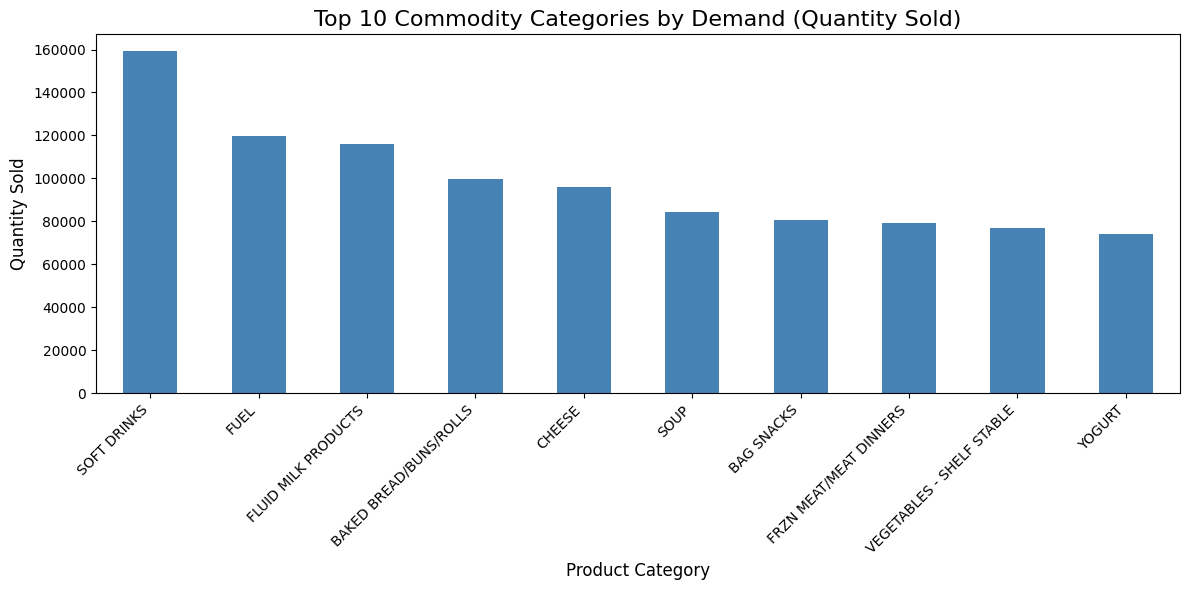

In [42]:
plt.figure(figsize=(12,6))
category_demand.plot(kind='bar', color='steelblue')
plt.title("Top 10 Commodity Categories by Demand (Quantity Sold)", fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The chart shows that Soft Drinks recoreded the highest sales followed by fuel and fluid milk products.

COUPON IMPACT ANALYSIS

In [43]:
coupon_analysis = (
    retail_df_backup.groupby("COUPON_USED")["NET_SALES"]
    .agg(['count','mean','sum', 'median'])
)
print(coupon_analysis)

               count      mean         sum  median
COUPON_USED                                       
0            1685520  2.541564  4283856.18    1.71
1             910212  2.554443  2325084.71    1.69


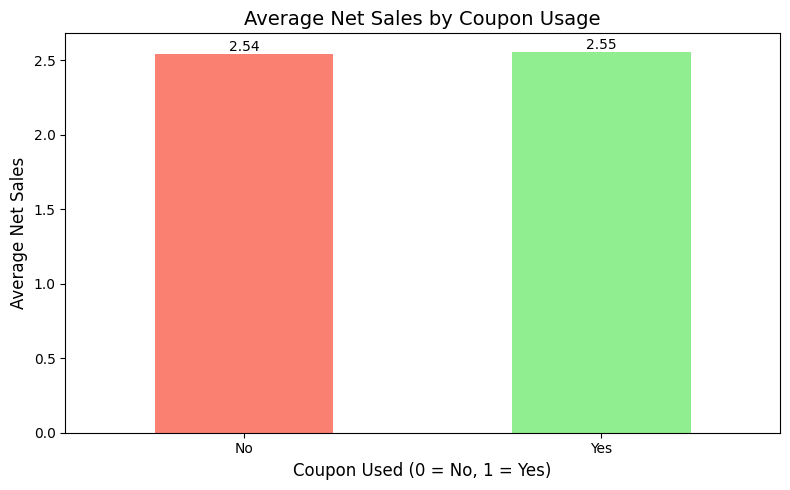

In [44]:
plt.figure(figsize=(8,5))
ax =coupon_analysis['mean'].plot(kind='bar', color=['salmon', 'lightgreen'])
plt.title("Average Net Sales by Coupon Usage", fontsize=14)
plt.xlabel("Coupon Used (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Average Net Sales", fontsize=12)
plt.xticks([0, 1], ["No", "Yes"], rotation=0)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

The chart shows that the avg net sales for both groups are similar, wherein Coupon users have a slightly higher avg than non coupon users. This indicates that coupon users only had a marginal impact on average transaction value .

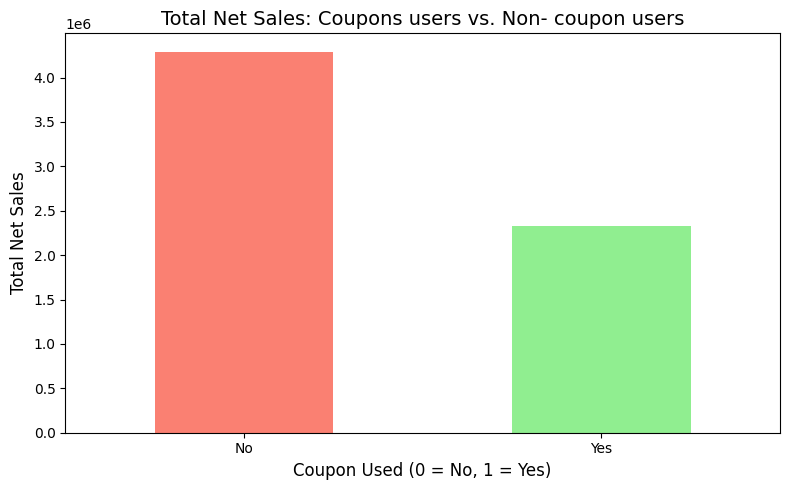

In [45]:
coupon_sales= (retail_df_backup.groupby("COUPON_USED")["NET_SALES"].sum())
plt.figure(figsize=(8,5))
coupon_sales.plot(kind='bar', color=['salmon', 'lightgreen'])
plt.title("Total Net Sales: Coupons users vs. Non- coupon users", fontsize=14)
plt.xlabel("Coupon Used (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Total Net Sales", fontsize=12)
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()

The chart shows that Non coupon users have generated more net sales than coupon users. This difference reflects the overall sales contribution of each group and suggests that non coupon transactions accounted for a larger share of total revenue.

REVENUE BY INCOME GROUP

In [46]:
income_order = [
    "Under 15K",
    "15-24K",
    "25-34K",
    "35-49K",
    "50-74K",
    "75-99K",
    "100-124K",
    "125-149K",
    "150-174K",
    "175-199K",
    "200-249K",
    "250K+"
]
income_revenue = (
    retail_df_backup.groupby("INCOME_DESC")["NET_SALES"].sum().reindex(income_order))

print(income_revenue)

INCOME_DESC
Under 15K    258504.43
15-24K       238816.34
25-34K       299666.37
35-49K       650052.71
50-74K       856608.59
75-99K       440412.50
100-124K     168890.97
125-149K     254600.55
150-174K     197354.60
175-199K      82654.03
200-249K      25200.77
250K+        103794.79
Name: NET_SALES, dtype: float64


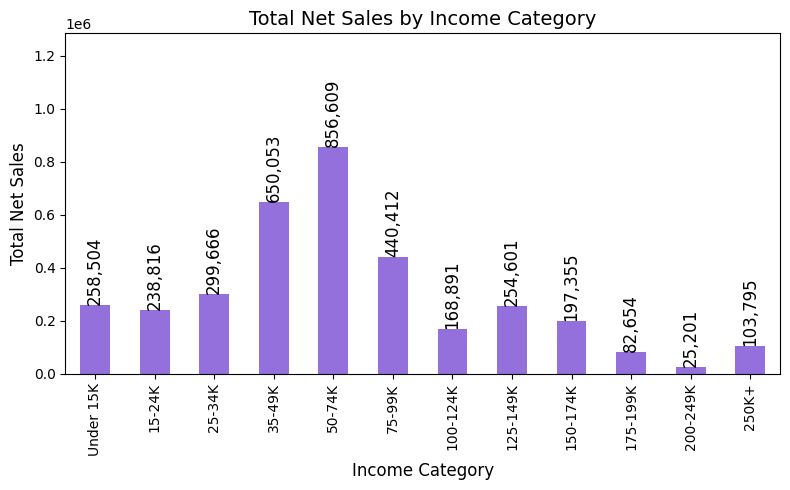

In [47]:
plt.figure(figsize=(8,5))
ax = income_revenue.plot(kind='bar', color='mediumpurple')
plt.title("Total Net Sales by Income Category", fontsize=14)
plt.xlabel("Income Category", fontsize=12)
plt.ylabel("Total Net Sales", fontsize=12)
plt.ylim(0, income_revenue.max() * 1.5)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=12,
        rotation=90
    )
plt.tight_layout()
plt.show()

The $50K–$74K income category generated the highest total net sales, followed by the $35K–$49K and $75K–$99K groups. In contrast, the $200K–$249K and 250K+ income categories contributed the lowest total net sales. This analysis highlighted the variations in purchasing behavior across income groups and identifies the segments with the greatest contribution to retail sales.

REVENUE BY DEPARTMENT

In [48]:
department_revenue = (
    retail_df_backup.groupby("DEPARTMENT")["NET_SALES"].sum().sort_values(ascending=False).head(10)
)
print(department_revenue)

DEPARTMENT
GROCERY            3225204.77
DRUG GM             933869.62
KIOSK-GAS           526996.84
PRODUCE             479216.62
MEAT                371652.47
MEAT-PCKGD          290831.43
DELI                234823.36
MISC SALES TRAN     116914.35
PASTRY              101950.85
NUTRITION            84828.95
Name: NET_SALES, dtype: float64


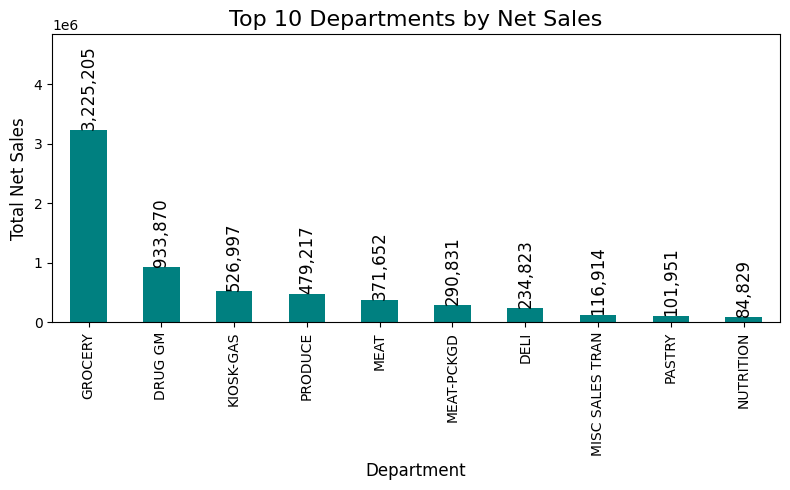

In [49]:
plt.figure(figsize=(8,5))
ax = department_revenue.plot(kind='bar', color='teal')
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=12,
        rotation=90
    )
plt.title("Top 10 Departments by Net Sales", fontsize=16)
plt.xlabel("Department", fontsize=12)
plt.ylabel("Total Net Sales", fontsize=12)
plt.ylim(0, department_revenue.max() * 1.5)
plt.tight_layout()
plt.show()

The Grocery department generated the highest net sales by a significant margin, followed by Drug GM and Kiosk-Gas. The remaining departments contributed comparatively lower net sales, indicating that a substantial portion of total revenue is concentrated within a few key departments. This analysis helped identify the primary revenue-generating areas in the retail dataset.

Correlation Analysis of Sales Metrics

In [50]:

correlation_data = retail_df_backup[
    ['QUANTITY', 'SALES_VALUE', 'NET_SALES', 'TOTAL_DISCOUNT']
]

correlation_matrix = correlation_data.corr()

print(correlation_matrix)

                QUANTITY  SALES_VALUE  NET_SALES  TOTAL_DISCOUNT
QUANTITY        1.000000     0.587993   0.594693       -0.036822
SALES_VALUE     0.587993     1.000000   0.952165       -0.250284
NET_SALES       0.594693     0.952165   1.000000        0.057549
TOTAL_DISCOUNT -0.036822    -0.250284   0.057549        1.000000


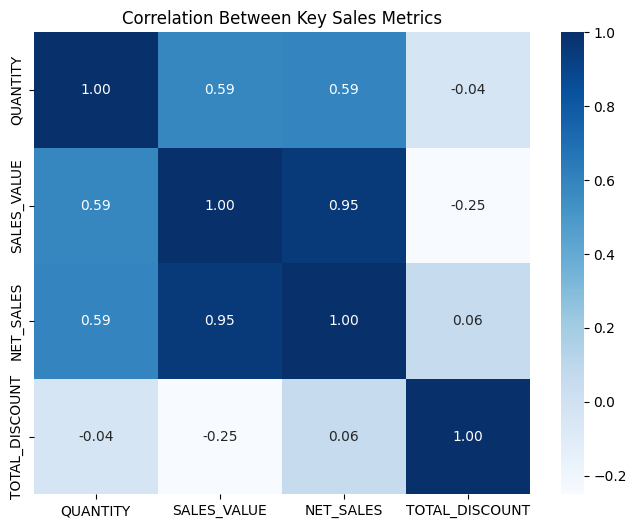

In [51]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Key Sales Metrics")
plt.show()

The analysis indicates that Sales Value and Quantity Sold are the primary drivers of Net Sales, while discounts have only a limited direct impact on overall revenue.

FINAL DATA VALIDATION

In [52]:

print(' Final Dataset Shape')
print(retail_df.shape)


print('Missing values')
print(retail_df.isnull().sum())


print("DUPLICATE RECORDS")
print(retail_df.duplicated().sum())

print('Data types')
print(retail_df.dtypes)

print('Data description')
print(retail_df.describe())

print('Number of unique households in the dataset:')
print(retail_df['household_key'].nunique())

retail_df.to_csv("clean_retail_inventory.csv", index=False)
print("Data saved to 'clean_retail_inventory.csv' successfully!")

 Final Dataset Shape
(2595732, 30)
Missing values
household_key           0
BASKET_ID               0
DAY                     0
PRODUCT_ID              0
QUANTITY                0
SALES_VALUE             0
STORE_ID                0
RETAIL_DISC             0
TRANS_TIME              0
WEEK_NO                 0
COUPON_DISC             0
COUPON_MATCH_DISC       0
MANUFACTURER            0
DEPARTMENT              0
BRAND                   0
COMMODITY_DESC          0
SUB_COMMODITY_DESC      0
CURR_SIZE_OF_PRODUCT    0
AGE_DESC                0
MARITAL_STATUS_CODE     0
INCOME_DESC             0
HOMEOWNER_DESC          0
HH_COMP_DESC            0
HOUSEHOLD_SIZE_DESC     0
KID_CATEGORY_DESC       0
COUPON_COUNT            0
COUPON_USED             0
TOTAL_DISCOUNT          0
NET_SALES               0
PURCHASE_FREQUENCY      0
dtype: int64
DUPLICATE RECORDS
0
Data types
household_key             int64
BASKET_ID                 int64
DAY                       int64
PRODUCT_ID                int6

AFTER QUALITY

In [53]:
datasets = {
    "Transactions": transactions,
    "Products": products,
    "Demographics": demographics,
    "Coupons": coupons
}

In [54]:
after_quality = []
for name, df in datasets.items():
    after_quality.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Records": df.duplicated().sum(),
        "Unique Columns with Missing Values": df.isnull().any().sum()
    })
 
after_quality = pd.DataFrame(after_quality)
print(after_quality)


        Dataset     Rows  Columns  Missing Values  Duplicate Records  \
0  Transactions  2595732       12               0                  0   
1      Products    92353        7               0                  0   
2  Demographics      801        8               0                  0   
3       Coupons     2318        4               0                  0   

   Unique Columns with Missing Values  
0                                   0  
1                                   0  
2                                   0  
3                                   0  


BEFORE VS AFTER COMPARISON

In [55]:
comparison = before_quality.copy()
comparison['Rows(After)'] = after_quality['Rows']
comparison['Missing_Values(After)'] = after_quality['Missing Values']
comparison['Duplicate_Records(After)'] = after_quality['Duplicate Records']
comparison['Unique_Columns_with_Missing_Values(After)'] = after_quality['Unique Columns with Missing Values']
comparison


,Dataset,Rows,Columns,Missing Values,Duplicate Records,Unique Columns with Missing Values,Rows(After),Missing_Values(After),Duplicate_Records(After),Unique_Columns_with_Missing_Values(After)
0,Transactions,2596232,12,0,500,0,2595732,0,0,0
1,Products,92353,7,1848,0,2,92353,0,0,0
2,Demographics,801,8,40,0,2,801,0,0,0
3,Coupons,2368,4,0,50,0,2318,0,0,0
